# Vector fields and mixed systems

Everything so far has had one scalar unknown per point. Three things change when it has more,
and the library treats them differently:

| what you want | what to write | what carries it |
|---|---|---|
| a vector unknown, one component per direction | `FunctionSpace.H1(mesh, order, vdim=d)` | `u.val` is `(d,)`, `u.grad` is `(d, sdim)` |
| a field whose tangential or normal trace is what continues across a face | `FunctionSpace.ND` / `.RT` | `u.val` is `(sdim,)`, with `u.curl` or `u.div` and **no** `u.grad` |
| two unknowns in *different* families, coupled | one density over four slots, assembled block by block | `QuadratureKernel` directly |

The first two go through `PDEVariationalProblem` unchanged, so an elasticity or magnetostatics
inverse problem is written exactly like a scalar one. The third does not: a problem variable
has one space, so a saddle-point system is assembled from its blocks. This notebook does all
three, in that order.

## 1. Load modules

In [1]:
import os
import sys

sys.path.insert(0, os.environ.get("HIPPYMFEM_BASE_DIR", os.path.abspath("..")))

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from mpi4py import MPI
import mfem.par as mfem
import jax.numpy as jnp

import hippymfem as hm
from hippymfem import nb
from hippymfem.modeling.variables import STATE, PARAMETER, ADJOINT

## 2. A vector state: a beam of unknown stiffness

A cantilever, clamped on the left and pulled down at the free end. The displacement
$u$ is a two-component field in a quadratic Lagrange space, and the shear modulus
$\mu = e^{m}$ varies in space: two soft inclusions we will try to find from
measurements of the displacement.

`vdim=2` is the whole difference on the state side. The parameter stays a scalar field.

In [2]:
LX, LY, NX, NY = 2.0, 0.5, 48, 12
mesh = mfem.ParMesh(MPI.COMM_WORLD, mfem.Mesh.MakeCartesian2D(
    NX, NY, mfem.Element.QUADRILATERAL, False, LX, LY))

Vu = hm.FunctionSpace.H1(mesh, 2, vdim=2)     # displacement: two components per node
Vm = hm.FunctionSpace.H1(mesh, 1)             # log shear modulus: one
Vh = [Vu, Vm, Vu]

print("state: %d dofs, vdim %d" % (Vu.GlobalTrueVSize(), Vu.vdim))
print("parameter: %d dofs" % Vm.GlobalTrueVSize())

state: 4850 dofs, vdim 2
parameter: 637 dofs


## 3. The density, with tensors in it

Plane strain linear elasticity, weakly:

$$\int_\Omega 2\mu\,\varepsilon(u)\!:\!\varepsilon(p) + \lambda\,(\nabla\!\cdot u)(\nabla\!\cdot p)
\;-\; \int_{\Gamma_{\rm end}} t\cdot p ,\qquad \varepsilon(u)=\tfrac12(\nabla u + \nabla u^{\!\top}).$$

In the density `u.grad` is the $(\mathrm{vdim}, \mathrm{sdim})$ array $\partial u_i/\partial x_j$, so
`hm.sym` and `hm.div` mean what they say and `hm.inner` contracts both indices. The traction is a
boundary density, given to `bdr_varf` on the free end alone.

The clamp is one `DirichletBC` with a scalar value, which on a vector space applies to every
component; `component=` restricts it to one, which is how a roller support is written.

largest displacement 5.317e-02, beam thickness 0.50


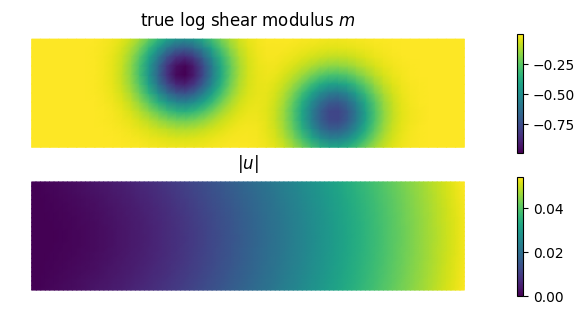

In [3]:
bottom, right, top, left = 1, 2, 3, 4
NU = 0.3                                     # Poisson ratio, through lambda/mu
LAM_OVER_MU = 2.0 * NU / (1.0 - 2.0 * NU)
TRACTION = np.array([0.0, -1.0e-3])          # downward, on the free end


def pde_varf(u, m, p, x):
    mu = jnp.exp(m.val)
    return (2.0 * mu * hm.inner(hm.sym(u.grad), hm.sym(p.grad))
            + LAM_OVER_MU * mu * hm.div(u.grad) * hm.div(p.grad))


def bdr_varf(u, m, p, x, n, h):
    return -jnp.dot(jnp.asarray(TRACTION), p.val)


bc = hm.DirichletBC(Vu, 0.0, bdr_attributes=[left])          # both components clamped
pde = hm.PDEVariationalProblem(Vh, pde_varf, bc, bc.homogeneous(), is_fwd_linear=True,
                               bdr_varf=bdr_varf, bdr_attributes=[right])
pde.set_solvers(hm.LUSolver, MPI.COMM_WORLD)

mtrue = Vm.project(lambda z: -1.0 * np.exp(-30.0 * ((z[0] - 0.7) ** 2 + (z[1] - 0.35) ** 2))
                   - 0.8 * np.exp(-30.0 * ((z[0] - 1.4) ** 2 + (z[1] - 0.15) ** 2)))
utrue = pde.generate_state()
pde.solveFwd(utrue, [utrue, mtrue, None])
print("largest displacement %.3e, beam thickness %.2f" % (np.abs(utrue.array).max(), LY))

plt.figure(figsize=(10, 3.4))
nb.plot(Vm, mtrue, subplot_loc=211, mytitle="true log shear modulus $m$")
nb.plot(Vu, utrue, subplot_loc=212, mytitle="$|u|$")
plt.show()

## 4. Observing a vector field

A point observation of a vector field has to say *what* is observed there, because a component
is a choice and not a default. `components` gives the weights across the components at each
target, so each point appears twice here, once reading $u_x$ and once $u_y$: what digital image
correlation delivers on a speckled surface. A single direction per point (`assemblePointwiseLOSObservation`)
is the line-of-sight version of the same thing.

In [4]:
gx, gy = np.meshgrid(np.linspace(0.12, 1.97, 24), np.linspace(0.04, 0.46, 8))
pts = np.column_stack((gx.ravel(), gy.ravel()))

targets = np.repeat(pts, 2, axis=0)                     # each point twice
comps = np.tile(np.eye(2), (pts.shape[0], 1))           # ... reading x, then y
B = hm.assemblePointwiseObservation(Vu, targets, components=comps)

data = B.createVecLeft()
B.mult(utrue, data)
noise_std = 0.002 * data.norm("linf")
hm.parRandom.set_seed(3)
B.perturb(data, noise_std)

prior = hm.BiLaplacianPrior(Vm, 0.2, 4.0, robin_bc=True)
model = hm.Model(pde, prior, hm.DiscreteStateObservation(B, data, noise_std ** 2))
print("%d points x 2 components = %d observations, noise std %.2e"
      % (pts.shape[0], targets.shape[0], noise_std))

192 points x 2 components = 384 observations, noise std 1.04e-04


## 5. The inverse problem, unchanged

Nothing below knows that the state has two components. `modelVerify` differentiates the same
density it always does, and Newton-CG runs on the same reduced problem.

      eps  ||err grad||     ||err H||        J(m+h)       slope g


 1.00e+00  1.268299e+05  1.174618e+04  2.196573e+05             -


 5.00e-01  5.182851e+04  5.237413e+03  1.134610e+05        1.2911


 2.50e-01  2.446154e+04  2.508378e+03  9.102179e+04        1.0832


 1.25e-01  1.208585e+04  1.252479e+03  8.509697e+04        1.0172


...

 7.45e-09  2.620367e+03  1.857932e+02  8.226608e+04       -0.6971


 3.73e-09  5.218648e+03  3.664587e+02  8.226608e+04       -0.9939


 1.86e-09  8.012390e+03  5.621018e+02  8.226608e+04       -0.6186


 9.31e-10  1.694055e+04  1.197489e+03  8.226608e+04       -1.0802


 4.66e-10  5.381962e+04  3.769901e+03  8.226608e+04       -1.6677


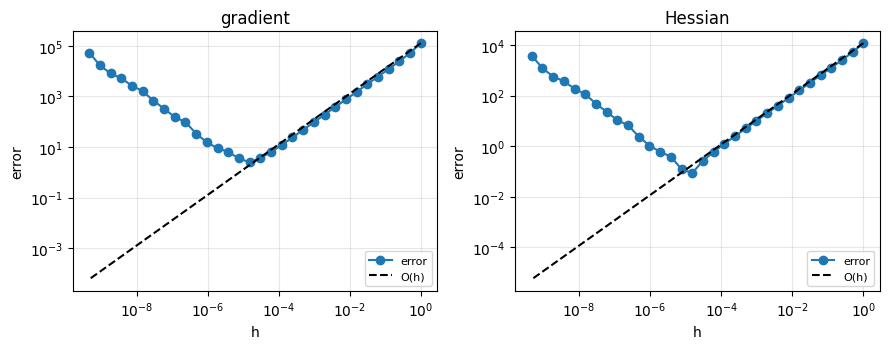

In [5]:
eps, err_grad, err_H = hm.modelVerify(model, prior.mean.copy(), plotting=True)
plt.show()

In [6]:
params = hm.ReducedSpaceNewtonCG_ParameterList()
params["rel_tolerance"] = 1e-9
params["max_iter"] = 25
params["print_level"] = -1

solver = hm.ReducedSpaceNewtonCG(model, params)
x = solver.solve([None, prior.mean.copy(), None])
err = mtrue.copy().axpy(-1.0, x[PARAMETER]).norm("l2") / mtrue.norm("l2")
print("%d Newton iterations, %d CG iterations, J = %.4e" % (
    solver.it, solver.total_cg_iter, solver.final_cost))
print("relative error in m: %.3f" % err)

15 Newton iterations, 126 CG iterations, J = 2.0143e+02
relative error in m: 0.263


## 6. Where the measurements reach

Both inclusions appear in the MAP estimate, the nearer one more strongly. The Laplace
approximation says why: the posterior standard deviation is smallest near the clamp, where a
change in stiffness changes the strain most, and grows towards the free end, where the beam
rotates almost rigidly and carries little information about the material under it.

prior std 0.319, posterior std between 0.077 and 0.263


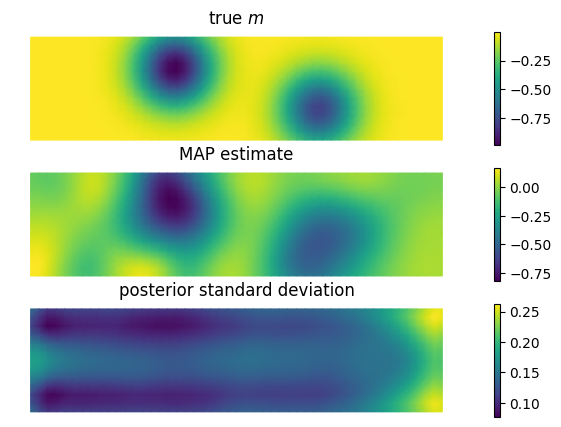

In [7]:
model.setPointForHessianEvaluations(x, gauss_newton_approx=False)
Hmisfit = hm.ReducedHessian(model, misfit_only=True)
k = 40
Omega = hm.MultiVector(x[PARAMETER], k + 5)
hm.parRandom.normal_multivector(1.0, Omega)
d, U = hm.doublePassG(Hmisfit, prior.R, prior.Rsolver, Omega, k)
post = hm.GaussianLRPosterior(prior, d, U, mean=x[PARAMETER])

pv_post, pv_prior, _ = post.pointwise_variance()
sd = Vm.vector()
sd.array[:] = np.sqrt(np.maximum(pv_post.array, 0.0))
print("prior std %.3f, posterior std between %.3f and %.3f"
      % (np.sqrt(pv_prior.array).mean(), sd.array.min(), sd.array.max()))

plt.figure(figsize=(10, 5))
nb.plot(Vm, mtrue, subplot_loc=311, mytitle="true $m$")
nb.plot(Vm, x[PARAMETER], subplot_loc=312, mytitle="MAP estimate")
nb.plot(Vm, sd, subplot_loc=313, mytitle="posterior standard deviation")
plt.show()

## 7. Families whose basis functions are vectors

Nedelec (`ND`, $H(\mathrm{curl})$) and Raviart-Thomas (`RT`, $H(\mathrm{div})$) elements have a vector
basis function per dof, and continue only the tangential or the normal trace across a face.
The density sees this: `u.val` is a vector, `u.curl` or `u.div` is available, and **`u.grad` is
not**, because the full gradient is not a member of the space and returning one would be a
quiet lie.

A 2D magnetostatics problem, then: the out-of-plane current $J$ drives a vector potential $A$,
$$\nabla\times(\nu\,\nabla\times A) + A = J,\qquad \nu = e^{m},$$
with the reluctivity $\nu$ of the material to be recovered from the field. The misfit is a
weighted $L^2$ one over the whole domain (`ContinuousStateObservation`), which is the natural
choice here since a point value of an $H(\mathrm{curl})$ field is not what an instrument reads.

In [8]:
mesh2 = mfem.ParMesh(MPI.COMM_WORLD, mfem.Mesh.MakeCartesian2D(20, 20, mfem.Element.TRIANGLE))
Va = hm.FunctionSpace.ND(mesh2, 1)          # H(curl)
Vn = hm.FunctionSpace.H1(mesh2, 1)


def current(x):
    swirl = jnp.array([-(x[1] - 0.5), x[0] - 0.5])
    return swirl * jnp.exp(-20.0 * ((x[0] - 0.5) ** 2 + (x[1] - 0.5) ** 2))


def curl_varf(u, m, p, x):
    nu = jnp.exp(m.val)
    return nu * u.curl * p.curl + jnp.dot(u.val, p.val) - jnp.dot(current(x), p.val)


bc2 = hm.DirichletBC(Va, None, bdr_attributes="all")     # tangential trace pinned
pde2 = hm.PDEVariationalProblem([Va, Vn, Va], curl_varf, bc2, bc2.homogeneous(),
                                is_fwd_linear=True)
pde2.set_solvers(hm.LUSolver, MPI.COMM_WORLD)

ntrue = Vn.project(lambda z: 1.2 * np.exp(-25.0 * ((z[0] - 0.35) ** 2 + (z[1] - 0.65) ** 2)))
atrue = pde2.generate_state()
pde2.solveFwd(atrue, [atrue, ntrue, None])
print("H(curl) state: %d dofs, |A| up to %.3e" % (Va.GlobalTrueVSize(), np.abs(atrue.array).max()))

H(curl) state: 1240 dofs, |A| up to 7.569e-05


gradient check on the H(curl) problem: first-order slope 1.067


10 Newton iterations, 362 CG iterations, relative error in m: 0.143


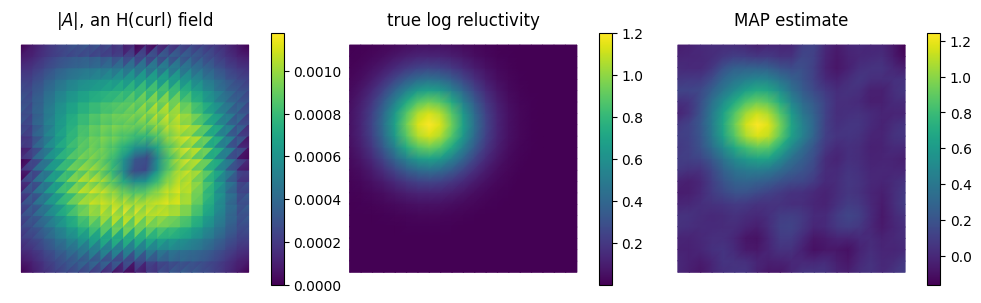

In [9]:
sigma = 0.01 * np.abs(atrue.array).max()
misfit = hm.ContinuousStateObservation(Va, noise_variance=sigma ** 2)
misfit.d.assign(atrue)
hm.parRandom.set_seed(5)
hm.parRandom.normal_perturb(sigma, misfit.d)

prior2 = hm.BiLaplacianPrior(Vn, 0.1, 2.0, robin_bc=True)
model2 = hm.Model(pde2, prior2, misfit)

eps2, eg2, eH2 = hm.modelVerify(model2, prior2.mean.copy(), plotting=False, verbose=False)
slope = np.polyfit(np.log(eps2[:5]), np.log(eg2[:5]), 1)[0]
print("gradient check on the H(curl) problem: first-order slope %.3f" % slope)

p2 = hm.ReducedSpaceNewtonCG_ParameterList()
p2["rel_tolerance"] = 1e-9
p2["max_iter"] = 20
p2["print_level"] = -1
s2 = hm.ReducedSpaceNewtonCG(model2, p2)
x2 = s2.solve([None, prior2.mean.copy(), None])
err2 = ntrue.copy().axpy(-1.0, x2[PARAMETER]).norm("l2") / ntrue.norm("l2")
print("%d Newton iterations, %d CG iterations, relative error in m: %.3f"
      % (s2.it, s2.total_cg_iter, err2))

plt.figure(figsize=(12, 3.6))
nb.plot(Va, atrue, subplot_loc=131, mytitle="$|A|$, an H(curl) field")
nb.plot(Vn, ntrue, subplot_loc=132, mytitle="true log reluctivity")
nb.plot(Vn, x2[PARAMETER], subplot_loc=133, mytitle="MAP estimate")
plt.show()

## 8. Two unknowns, two families

`PDEVariationalProblem` gives each of the three variables one space, so a saddle-point system
such as mixed Darcy, flux in $RT$ and pressure in $L^2$, does not fit it. The *differentiation*
fits it perfectly well: write the residual of the whole system as one density over four slots
(two trial, two test) and every block of the Jacobian is a second derivative of it, between
slots that happen to live in different families.

$$R(\sigma,u;\tau,v) = \int_\Omega K^{-1}\sigma\cdot\tau \;-\; u\,\nabla\!\cdot\tau
\;+\; v\,\nabla\!\cdot\sigma \;-\; f\,v .$$

A zero pressure on the boundary is *natural* here, so there is no essential condition to
impose, and the right-hand side is the residual evaluated at zero.

In [10]:
comm = MPI.COMM_WORLD
mesh3 = mfem.ParMesh(comm, mfem.Mesh.MakeCartesian2D(24, 24, mfem.Element.QUADRILATERAL))
Vs = hm.FunctionSpace.RT(mesh3, 1)       # flux
Vp = hm.FunctionSpace.L2(mesh3, 1)       # pressure
SIG, U, TAU, V = 0, 1, 2, 3              # trial sigma, trial u, test tau, test v
spaces = [Vs, Vp, Vs, Vp]
batches = hm.MeshBatches(mesh3, 6, comm)


def logK(x):
    return 0.8 * jnp.sin(4.0 * x[0]) * jnp.cos(3.0 * x[1])


def source(x):
    return (jnp.exp(-80.0 * ((x[0] - 0.3) ** 2 + (x[1] - 0.7) ** 2))
            - jnp.exp(-80.0 * ((x[0] - 0.7) ** 2 + (x[1] - 0.3) ** 2)))


def density(sigma, u, tau, v, x):
    return (jnp.exp(-logK(x)) * jnp.dot(sigma.val, tau.val)
            - u.val * tau.div + v.val * sigma.div - source(x) * v.val)


K = hm.QuadratureKernel(density, spaces, batches)
zero = [sp.local_values(sp.vector()) for sp in spaces]     # the density is bilinear
NE = mesh3.GetNE()


def blk(i, j):
    return hm.assemble_matrix(spaces[i], spaces[j], batches.groups,
                              K.element_matrices(i, j, zero), NE)


A11, A12, A21, A22 = blk(TAU, SIG), blk(TAU, U), blk(V, SIG), blk(V, U)
print("blocks: (%d,%d) (%d,%d) / (%d,%d) (%d,%d)"
      % (A11.Height(), A11.Width(), A12.Height(), A12.Width(),
         A21.Height(), A21.Width(), A22.Height(), A22.Width()))

blocks: (4704,4704) (4704,2304) / (2304,4704) (2304,2304)


The two off-diagonal blocks must be each other's negative transpose: that is the discrete
statement that the same divergence couples the two equations, and it holds here because both
came from the same mixed second derivative of the same density, on the same quadrature rule.
Testing it costs two matrix-vector products.

In [11]:
rng = np.random.default_rng(0)
xv, yv = Vp.vector(), Vs.vector()
xv.array[:] = rng.standard_normal(xv.local_size)
yv.array[:] = rng.standard_normal(yv.local_size)

t1, t2 = Vs.vector(), Vp.vector()
A12.Mult(xv.hypre, t1.hypre)          # A12 : pressure -> flux equation
A21.Mult(yv.hypre, t2.hypre)          # A21 : flux -> pressure equation
lhs, rhs_ = t1.inner(yv), t2.inner(xv)
print("y.A12 x = %+.8e,  x.A21 y = %+.8e,  sum/|term| = %.2e"
      % (lhs, rhs_, abs(lhs + rhs_) / max(abs(lhs), 1e-300)))

y.A12 x = +6.44627708e+01,  x.A21 y = -6.44627708e+01,  sum/|term| = 0.00e+00


The four blocks glue into one parallel matrix with MFEM's `HypreParMatrixFromBlocks`, and the
right-hand side is minus the residual at zero. The result is a symmetric indefinite system;
here it is small enough to factorize. (The concatenation below is the serial dof layout, which
is what this notebook runs on; in parallel the block offsets are per rank.)

In [12]:
r_tau = hm.assemble_vector(Vs, batches.groups, K.element_vectors(TAU, zero), NE)
r_v = hm.assemble_vector(Vp, batches.groups, K.element_vectors(V, zero), NE)

blocks = mfem.HypreParMatrixArray2D(2, 2)
blocks[0, 0], blocks[0, 1] = A11, A12
blocks[1, 0], blocks[1, 1] = A21, A22
mono = mfem.HypreParMatrixFromBlocks(blocks)

rhs = hm.ParVector(comm, mono.Height())
ns = Vs.vector().local_size
rhs.array[:ns] = -r_tau.array
rhs.array[ns:] = -r_v.array

sol = hm.ParVector(comm, mono.Height())
lu = hm.LUSolver(comm)
lu.set_operator(mono)
lu.solve(sol, rhs)

flux, pressure = Vs.vector(), Vp.vector()
flux.array[:] = sol.array[:ns]
pressure.array[:] = sol.array[ns:]
print("monolithic system: %d unknowns" % mono.GetGlobalNumRows())
print("pressure between %.4f and %.4f, |flux| up to %.4f"
      % (pressure.array.min(), pressure.array.max(), np.abs(flux.array).max()))

monolithic system: 7008 unknowns
pressure between -0.0074 and 0.0118, |flux| up to 0.0018


Is it right? Solve the same problem in its primal form, which *does* fit
`PDEVariationalProblem`, and compare the two pressures at two hundred random points. They are
different discretizations of the same equation, so they agree to discretization error and not
to round-off.

mixed vs primal pressure at 200 points: relative difference 3.41e-03


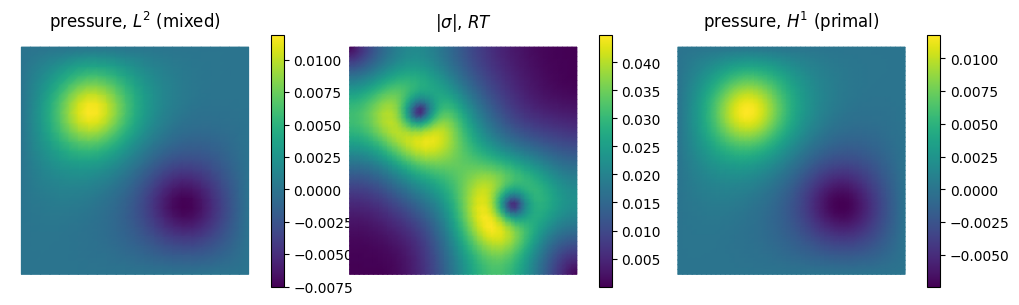

In [13]:
Vh1 = hm.FunctionSpace.H1(mesh3, 2)


def primal_varf(u, m, p, x):
    return jnp.exp(logK(x)) * hm.inner(u.grad, p.grad) - source(x) * p.val


bc3 = hm.DirichletBC(Vh1, 0.0, bdr_attributes="all")
pde3 = hm.PDEVariationalProblem([Vh1, Vp, Vh1], primal_varf, bc3, bc3.homogeneous(),
                                is_fwd_linear=True)
pde3.set_solvers(hm.LUSolver, comm)
uprimal = pde3.generate_state()
pde3.solveFwd(uprimal, [uprimal, Vp.vector(), None])

tg = np.column_stack((rng.uniform(0.05, 0.95, 200), rng.uniform(0.05, 0.95, 200)))
Bm = hm.assemblePointwiseObservation(Vp, tg)
Bp = hm.assemblePointwiseObservation(Vh1, tg)
a = Bm.gather(Bm.mult(pressure, Bm.createVecLeft()))
b = Bp.gather(Bp.mult(uprimal, Bp.createVecLeft()))
print("mixed vs primal pressure at 200 points: relative difference %.2e"
      % (np.linalg.norm(a - b) / np.linalg.norm(b)))

plt.figure(figsize=(12, 3.6))
nb.plot(Vp, pressure, subplot_loc=131, mytitle="pressure, $L^2$ (mixed)")
nb.plot(Vs, flux, subplot_loc=132, mytitle="$|\\sigma|$, $RT$")
nb.plot(Vh1, uprimal, subplot_loc=133, mytitle="pressure, $H^1$ (primal)")
plt.show()

## What to take from this

- A **vector Lagrange** state costs one keyword, `vdim=d`. In the density `u.grad` is
  $\partial u_i/\partial x_j$, and `hm.sym`, `hm.div`, `hm.inner` read as they do on paper. An
  observation of a vector field must say which component or direction it reads.
- **$H(\mathrm{curl})$ and $H(\mathrm{div})$** spaces work the same way through
  `PDEVariationalProblem`, with `u.curl` and `u.div` in place of `u.grad`. Their basis functions
  are Piola mapped and their orientation corrections are applied exactly where MFEM applies
  them, checked against `CurlCurlIntegrator`, `DivDivIntegrator` and `VectorFEMassIntegrator` in
  `hippymfem/test/test_vectorfe.py`.
- A **system whose fields live in different families** is outside `PDEVariationalProblem`, which
  gives each variable one space, but not outside the kernel: write one density over all the
  slots, take the blocks you need, and glue them. The derivatives across families are as exact
  as the ones within a family.
- What none of this changed: the gradient, the Hessian, `modelVerify`, Newton-CG and the
  Laplace posterior. They see element arrays, not element families.

Next: [12_ForwardUQ](12_ForwardUQ.ipynb) asks what all of this predicts, as a single
number with an error bar.

`hippymfem/test/test_vectorfe.py` carries the same three cases as tests, including a
poroelasticity system (displacement in a vector $H^1$ space, pressure in a scalar one) whose
four blocks come from one density; `docs/source/guide/spaces.rst` is the reference for what each
family gives the density.